Phishing URL Detection — Random Forest Classifier

## 1. Install & Import Libraries

In [1]:
# Install required libraries if needed
!pip install pandas numpy scikit-learn matplotlib seaborn tldextract joblib

In [2]:
import pandas as pd
import numpy as np
import re
import tldextract
import warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load Dataset

In [3]:
# Load the dataset
df = pd.read_csv('urls.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (822010, 2)
Columns: ['url', 'status']


,url,status
0,0000111servicehelpdesk.godaddysites.com,0
1,000011accesswebform.godaddysites.com,0
2,00003.online,0
3,0009servicedeskowa.godaddysites.com,0
4,000n38p.wcomhost.com,0


In [4]:
# ── Adapt column names to your actual CSV
URL_COL    = 'url'
LABEL_COL  = 'status'

print(f"Label distribution:\n{df[LABEL_COL].value_counts()}")
print(f"\nNull values:\n{df[[URL_COL, LABEL_COL]].isnull().sum()}")

Label distribution:
status
1    427028
0    394982
Name: count, dtype: int64

Null values:
url       0
status    0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

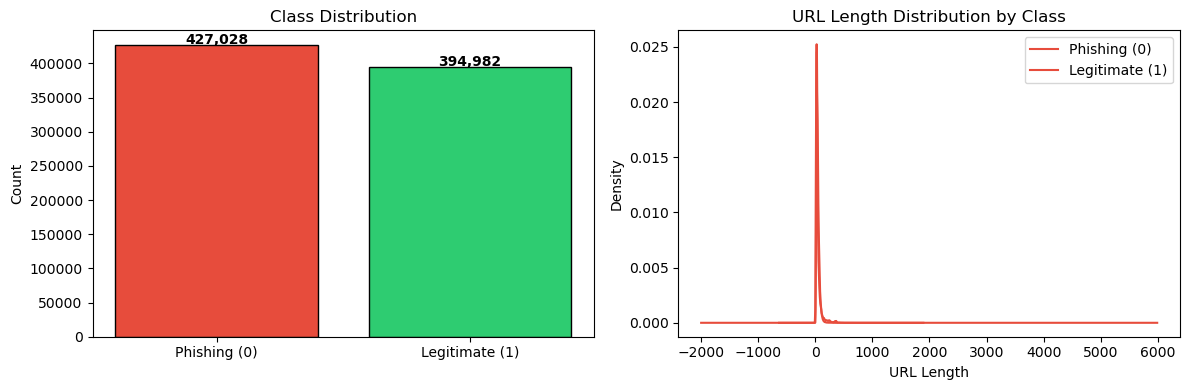

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution bar chart
counts = df[LABEL_COL].value_counts()
axes[0].bar(['Phishing (0)', 'Legitimate (1)'], counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# URL length distribution
df['url_length'] = df[URL_COL].astype(str).apply(len)
df.groupby(LABEL_COL)['url_length'].plot(kind='kde', ax=axes[1], legend=True,
                                          color=['#e74c3c', '#2ecc71'])
axes[1].set_title('URL Length Distribution by Class')
axes[1].set_xlabel('URL Length')
axes[1].legend(['Phishing (0)', 'Legitimate (1)'])

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [6]:
def extract_features(url: str) -> dict:
    """Extract lexical and structural features from a URL string."""
    url = str(url)
    ext = tldextract.extract(url)

    # Basic length features 
    features = {
        'url_length'         : len(url),
        'domain_length'      : len(ext.domain),
        'path_length'        : len(url.split('/', 3)[-1]) if '/' in url else 0,
        'subdomain_length'   : len(ext.subdomain),
        'tld_length'         : len(ext.suffix),

        # Character counts 
        'num_dots'           : url.count('.'),
        'num_hyphens'        : url.count('-'),
        'num_underscores'    : url.count('_'),
        'num_slashes'        : url.count('/'),
        'num_question_marks' : url.count('?'),
        'num_equals'         : url.count('='),
        'num_at'             : url.count('@'),
        'num_ampersand'      : url.count('&'),
        'num_exclamation'    : url.count('!'),
        'num_space'          : url.count(' '),
        'num_tilde'          : url.count('~'),
        'num_comma'          : url.count(','),
        'num_plus'           : url.count('+'),
        'num_asterisk'       : url.count('*'),
        'num_hash'           : url.count('#'),
        'num_dollar'         : url.count('$'),
        'num_percent'        : url.count('%'),
        'num_digits'         : sum(c.isdigit() for c in url),

        # Ratio features 
        'digit_ratio'        : sum(c.isdigit() for c in url) / max(len(url), 1),
        'letter_ratio'       : sum(c.isalpha() for c in url) / max(len(url), 1),

        # Structural / suspicious flags 
        'has_https'          : int(url.startswith('https')),
        'has_http'           : int(url.startswith('http://')),
        'has_ip_address'     : int(bool(re.search(
                                    r'(\d{1,3}\.){3}\d{1,3}', url))),
        'has_at_symbol'      : int('@' in url),
        'has_double_slash'   : int('//' in url[7:]),   # skip scheme
        'has_hex_encoding'   : int('%' in url),
        'has_port'           : int(bool(re.search(r':\d{2,5}/', url))),
        'subdomain_count'    : len(ext.subdomain.split('.')) if ext.subdomain else 0,
        'is_shortened'       : int(ext.domain in {
                                    'bit', 'tinyurl', 'goo', 't',
                                    'ow', 'is', 'cli', 'yfrog', 'migre'}),
        'token_count'        : len(re.split(r'[\W_]+', url)),
        'suspicious_words'   : int(bool(re.search(
                                    r'login|verify|update|secure|account'
                                    r'|banking|confirm|password|signin|ebayisapi'
                                    r'|webscr|paypal|free|lucky|service|bonus',
                                    url, re.IGNORECASE))),
    }
    return features

print('Feature extraction function defined')
print('Sample features for first URL:')
sample = extract_features(df[URL_COL].iloc[0])
for k, v in sample.items():
    print(f'  {k:25s}: {v}')

Feature extraction function defined
Sample features for first URL:
  url_length               : 39
  domain_length            : 12
  path_length              : 0
  subdomain_length         : 22
  tld_length               : 3
  num_dots                 : 2
  num_hyphens              : 0
  num_underscores          : 0
  num_slashes              : 0
  num_question_marks       : 0
  num_equals               : 0
  num_at                   : 0
  num_ampersand            : 0
  num_exclamation          : 0
  num_space                : 0
  num_tilde                : 0
  num_comma                : 0
  num_plus                 : 0
  num_asterisk             : 0
  num_hash                 : 0
  num_dollar               : 0
  num_percent              : 0
  num_digits               : 7
  digit_ratio              : 0.1794871794871795
  letter_ratio             : 0.7692307692307693
  has_https                : 0
  has_http                 : 0
  has_ip_address           : 0
  has_at_symbol            :

In [7]:
print('Extracting features from all URLs…')
features_df = pd.DataFrame([extract_features(u) for u in df[URL_COL]])
print(f'Feature matrix shape: {features_df.shape}')
features_df.head()

Extracting features from all URLs…
Feature matrix shape: (822010, 36)


,url_length,domain_length,path_length,subdomain_length,tld_length,num_dots,num_hyphens,num_underscores,num_slashes,num_question_marks,...,has_http,has_ip_address,has_at_symbol,has_double_slash,has_hex_encoding,has_port,subdomain_count,is_shortened,token_count,suspicious_words
0,39,12,0,22,3,2,0,0,0,0,...,0,0,0,0,0,0,1,0,3,1
1,36,12,0,19,3,2,0,0,0,0,...,0,0,0,0,0,0,1,0,3,0
2,12,5,0,0,6,1,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
3,35,12,0,18,3,2,0,0,0,0,...,0,0,0,0,0,0,1,0,3,1
4,20,8,0,7,3,2,0,0,0,0,...,0,0,0,0,0,0,1,0,3,0


## 5. Prepare Train / Test Split

In [8]:
X = features_df
y = df[LABEL_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print(f'Feature count    : {X_train.shape[1]}')

Training samples : 657,608
Test samples     : 164,402
Feature count    : 36


## 6. Train the Random Forest Model

In [9]:
rf_model = RandomForestClassifier(
    n_estimators    = 50,       
    max_depth       = None,        
    min_samples_split = 2,
    min_samples_leaf  = 2,
    max_features    = 'log2',    
    class_weight    = 'balanced',
    n_jobs          = -1,        
    random_state    = 42,
    verbose         = 1
)

print('Training Random Forest…')
rf_model.fit(X_train, y_train)
print('Training complete ')

Training Random Forest…


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    7.1s


Training complete 


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   12.7s finished


## 7. Evaluate the Model

In [10]:
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'ROC-AUC  : {roc_auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Phishing (0)', 'Legitimate (1)']))

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s


Accuracy : 0.9504 (95.04%)
ROC-AUC  : 0.9893

Classification Report:
                precision    recall  f1-score   support

  Phishing (0)       0.96      0.94      0.95     78996
Legitimate (1)       0.94      0.96      0.95     85406

      accuracy                           0.95    164402
     macro avg       0.95      0.95      0.95    164402
  weighted avg       0.95      0.95      0.95    164402



[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.2s finished


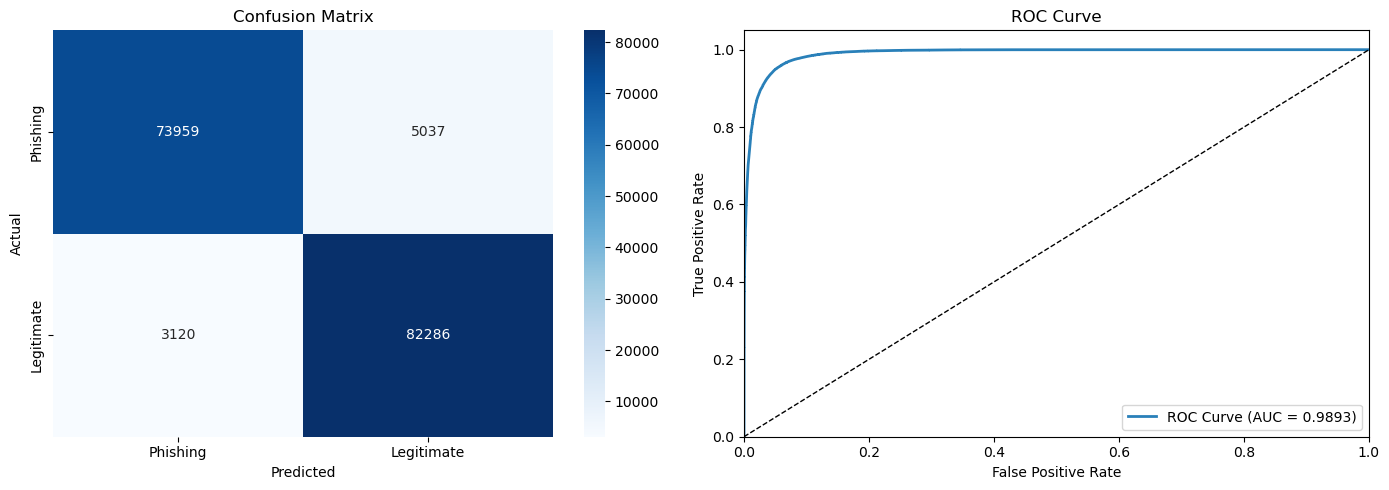

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Phishing', 'Legitimate'],
            yticklabels=['Phishing', 'Legitimate'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve 
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 8. Feature Importance

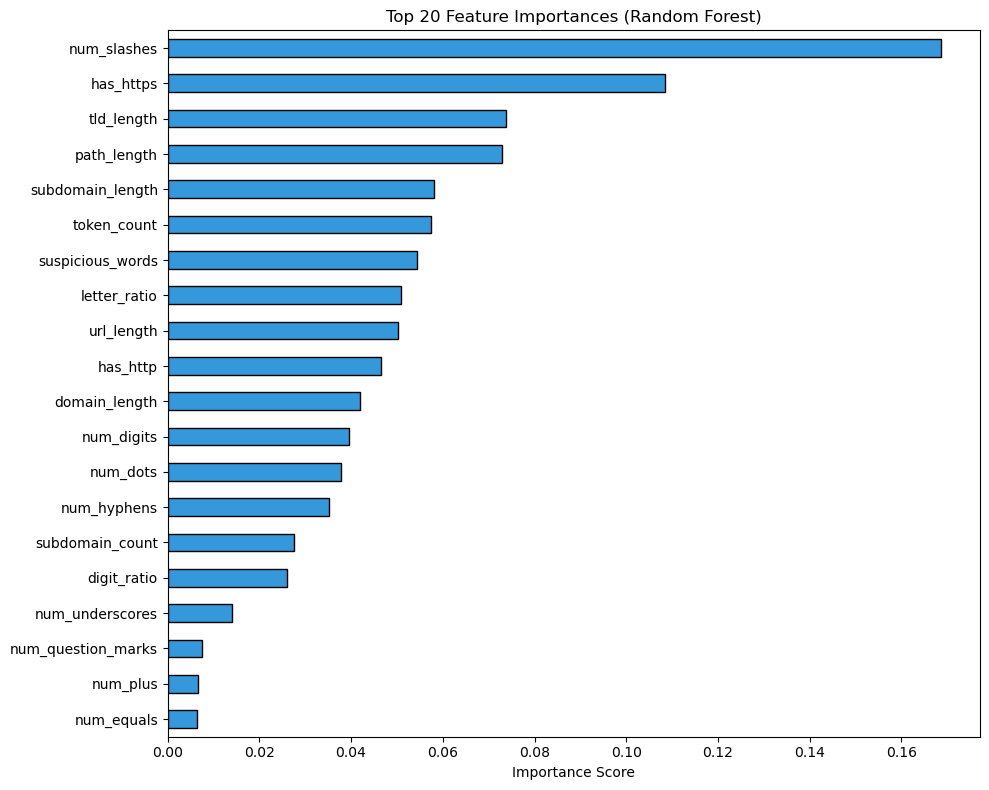


Top 10 most important features:
num_slashes         0.168731
has_https           0.108409
tld_length          0.073770
path_length         0.072829
subdomain_length    0.058167
token_count         0.057349
suspicious_words    0.054267
letter_ratio        0.050922
url_length          0.050199
has_http            0.046572
dtype: float64


In [12]:
importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.tail(20).plot(kind='barh', color='#3498db', edgecolor='black')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
print(importances.tail(10).sort_values(ascending=False))

## 9. Hyperparameter Tuning

In [13]:
# from sklearn.model_selection import RandomizedSearchCV

# param_grid = {
#     'n_estimators'     : [50, 100, 200],
#     'max_depth'        : [10, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'max_features'     : ['sqrt', 'log2'],
# }

# search = RandomizedSearchCV(
#     RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
#     param_distributions=param_grid,
#     n_iter=20, cv=3, scoring='roc_auc',
#     verbose=2, random_state=42
# )
# search.fit(X_train, y_train)
# print('Best params:', search.best_params_)
# print('Best ROC-AUC:', search.best_score_)
# print('Hyperparameter tuning cell ready')

## 10. Save the Model

In [14]:
MODEL_PATH = 'phishing_rf_model.joblib'
joblib.dump(rf_model, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

Model saved to phishing_rf_model.joblib


## 11. Predict on New URLs

In [15]:
def predict_url(url: str, model=rf_model) -> dict:
    """Predict whether a URL is phishing or legitimate."""
    feats   = pd.DataFrame([extract_features(url)])
    label   = model.predict(feats)[0]
    prob    = model.predict_proba(feats)[0]
    return {
        'url'        : url,
        'prediction' : 'Legitimate' if label == 1 else 'Phishing',
        'confidence' : f'{max(prob)*100:.2f}%'
    }

# Test with sample URLs 
test_urls = [
    'https://www.google.com/search?q=openai',
    'http://192.168.1.1/login/verify-account?user=admin&token=x93mf',
    'http://paypa1-secure-login.com/update/confirm',
    'https://github.com/scikit-learn/scikit-learn',
]

results = pd.DataFrame([predict_url(u) for u in test_urls])
print(results.to_string(index=False))

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0

                                                           url prediction confidence
                        https://www.google.com/search?q=openai Legitimate     58.31%
http://192.168.1.1/login/verify-account?user=admin&token=x93mf   Phishing     97.50%
                 http://paypa1-secure-login.com/update/confirm   Phishing     70.05%
                  https://github.com/scikit-learn/scikit-learn Legitimate     87.80%


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
